In [2]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision.transforms import transforms

# device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# for consistent results
torch.manual_seed(42)

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
]) 

In [22]:
train = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform)
test = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train, batch_size=64, shuffle=True) # Required to shuffle
test_loader = DataLoader(test, batch_size=64)

In [23]:
unilayer = nn.Linear(50, 20)

In [24]:
class DeepNetwork(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.flatten = nn.Flatten()
        self.input = nn.Linear(input_size, 1024)

        self.hidden = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.output = nn.Linear(64, output_size)

    def forward(self, x):
        x = self.flatten(x)
        x = self.input(x)
        x = self.hidden(x)
        return self.output(x)

In [25]:
model = DeepNetwork(784, 10) # MNIST is 28x28 -> 784
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()
epochs = 5

In [26]:
from tqdm import tqdm

for epoch in range(epochs):
    loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/epoch", leave=True) # Visualizer
    for imgs, labels in loop:
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=f"{loss.item():.4f}")
    print(f"Epoch {epoch+1} done")

Epoch 1/epoch: 100%|██████████| 938/938 [00:09<00:00, 94.41it/s, loss=0.4030] 


Epoch 1 done


Epoch 2/epoch: 100%|██████████| 938/938 [00:10<00:00, 90.39it/s, loss=0.4693] 


Epoch 2 done


Epoch 3/epoch: 100%|██████████| 938/938 [00:10<00:00, 89.77it/s, loss=0.1079] 


Epoch 3 done


Epoch 4/epoch: 100%|██████████| 938/938 [00:10<00:00, 91.25it/s, loss=0.0151] 


Epoch 4 done


Epoch 5/epoch: 100%|██████████| 938/938 [00:10<00:00, 92.17it/s, loss=0.0645] 

Epoch 5 done


In [27]:
torch.save(model, './model.torch')

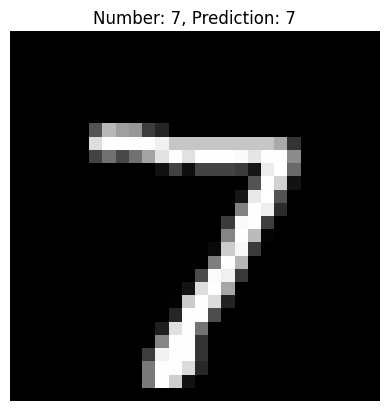

In [33]:
import matplotlib.pyplot as plt

sample_img, real_val = next(iter(test_loader))

predicted_val = model(sample_img).argmax(dim=1)[0].item()

plt.imshow(sample_img[0].squeeze().numpy(), cmap='gray')
plt.title(f"Number: {real_val[0].item()}, Prediction: {predicted_val}")
plt.axis('off')
plt.show()